# Assignment 2: GAN and Diffusion Model
## Section 2: Wasserstein GAN (WGAN) Implementation
### Prasanna Paithankar (21CS30065)

11th March 2026

In [1]:
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from rich.progress import Progress
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
lr = 0.0002
lr_wgan = 0.00005
b1 = 0.5
b2 = 0.999
batch_size = 128
epochs = 50
clip_value = 0.01
critic_iters = 5
latent_dim = 100
img_shape = (1, 28, 28)

In [3]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

mnist_data = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
dataloader = DataLoader(mnist_data, batch_size=batch_size, shuffle=True, drop_last=True)

In [4]:
class Generator(nn.Module):
    def __init__(self, latent_dim, num_classes: Optional[int] = None):
        super(Generator, self).__init__()
        self.num_classes = num_classes

        input_dim = latent_dim + (num_classes if num_classes else 0)

        if num_classes is not None:
            self.label_embedding = nn.Embedding(num_classes, num_classes)

        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, int(np.prod(img_shape))),
            nn.Tanh(),
        )

    def forward(self, noise, labels=None):
        if self.num_classes and labels is not None:
            c = self.label_embedding(labels)
            x = torch.cat([noise, c], dim=1)
        else:
            x = noise

        img = self.model(x)
        return img.view(img.size(0), *img_shape)


class Critic(nn.Module):
    def __init__(self, num_classes: Optional[int] = None):
        super(Critic, self).__init__()
        self.num_classes = num_classes
        input_dim = int(np.prod(img_shape)) + (num_classes if num_classes else 0)

        if num_classes is not None:
            self.label_embedding = nn.Embedding(num_classes, num_classes)

        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
        )

    def forward(self, img, labels=None):
        if self.num_classes is not None and labels is not None:
            c = self.label_embedding(labels)
            img_flat = img.view(img.size(0), -1)
            x = torch.cat([img_flat, c], dim=1)
        else:
            x = img.view(img.size(0), -1)

        validity = self.model(x)
        return validity

In [5]:
def train_wgan(generator, critic, epochs=50, conditional=False):
    optimizer_G = optim.RMSprop(generator.parameters(), lr=lr_wgan)
    optimizer_C = optim.RMSprop(critic.parameters(), lr=lr_wgan)

    c_losses = []
    g_losses = []

    static_noise = torch.randn(25, latent_dim, device=device)
    static_labels = None
    if conditional:
        if getattr(generator, "num_classes", None) is None:
            raise ValueError(
                "Generator must have num_classes set when conditional=True."
            )
        static_labels = torch.randint(0, generator.num_classes, (25,), device=device)

    total_steps = epochs * len(dataloader)

    with Progress() as progress:
        train_task = progress.add_task("[cyan]Training WGAN...", total=total_steps)

        for epoch in range(epochs):
            epoch_c_loss = 0.0
            epoch_g_loss = 0.0
            g_iters = 0

            for i, (imgs, labels) in enumerate(dataloader):
                real_imgs = imgs.to(device)
                labels = labels.to(device) if conditional else None
                batch_size = imgs.size(0)

                optimizer_C.zero_grad()

                z = torch.randn(batch_size, latent_dim, device=device)
                fake_imgs = (
                    generator(z, labels).detach()
                    if conditional
                    else generator(z).detach()
                )

                loss_C = -torch.mean(critic(real_imgs, labels)) + torch.mean(
                    critic(fake_imgs, labels)
                )
                loss_C.backward()
                optimizer_C.step()

                for p in critic.parameters():
                    p.data.clamp_(-clip_value, clip_value)

                epoch_c_loss += loss_C.item()

                if i % critic_iters == 0:
                    optimizer_G.zero_grad()

                    gen_imgs = generator(z, labels) if conditional else generator(z)
                    loss_G = -torch.mean(critic(gen_imgs, labels))

                    loss_G.backward()
                    optimizer_G.step()

                    epoch_g_loss += loss_G.item()
                    g_iters += 1

                progress.advance(train_task, 1)

            avg_c_loss = epoch_c_loss / len(dataloader)
            avg_g_loss = epoch_g_loss / max(g_iters, 1)
            c_losses.append(avg_c_loss)
            g_losses.append(avg_g_loss)

            if (epoch + 1) % 10 == 0:
                generator.eval()
                with torch.no_grad():
                    gen_imgs = (
                        generator(static_noise, static_labels).cpu()
                        if conditional
                        else generator(static_noise).cpu()
                    )
                generator.train()

                _, axes = plt.subplots(5, 5, figsize=(5, 5))
                for idx, ax in enumerate(axes.flatten()):
                    ax.imshow(gen_imgs[idx][0], cmap="gray")
                    ax.axis("off")
                plt.suptitle(f"WGAN Generated Images - Epoch {epoch + 1}")
                plt.tight_layout()
                plt.show()

    return c_losses, g_losses

Output()

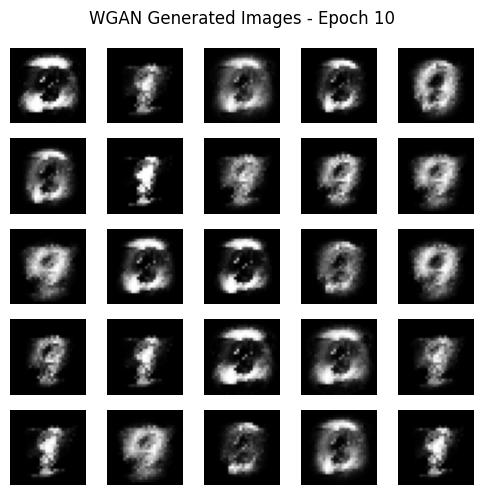

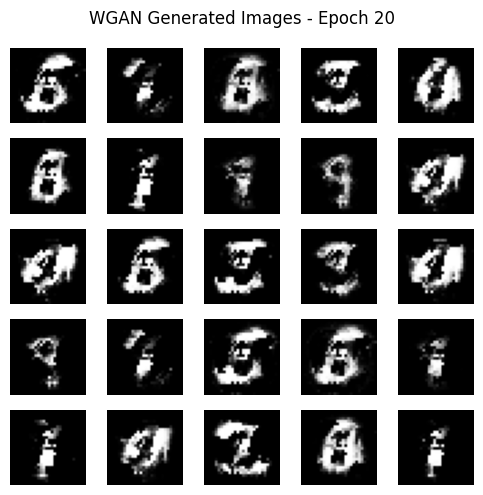

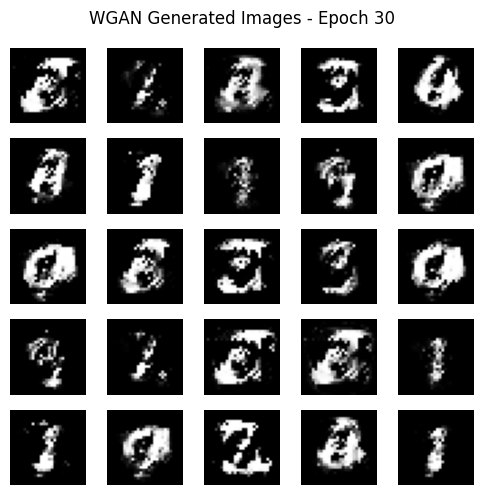

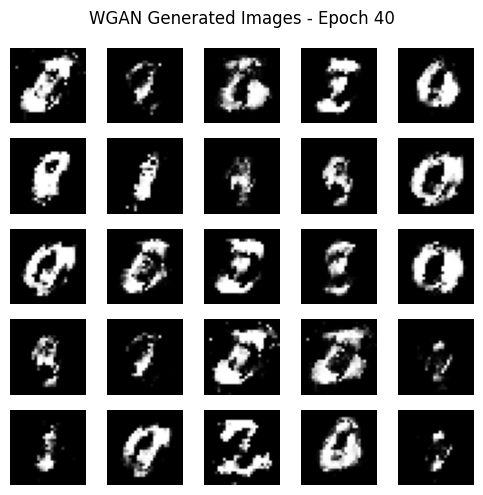

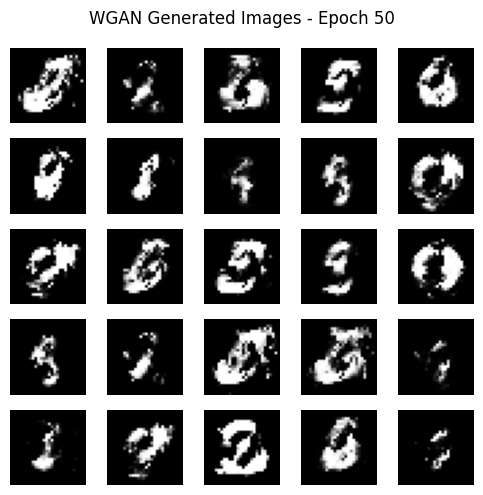

In [6]:
wgan_G = Generator(latent_dim).to(device)
wgan_C = Critic().to(device)

c_loss_history, g_loss_history = train_wgan(wgan_G, wgan_C, epochs=50)

torch.save(wgan_G.state_dict(), "wgan_generator.pth")
torch.save(wgan_C.state_dict(), "wgan_critic.pth")

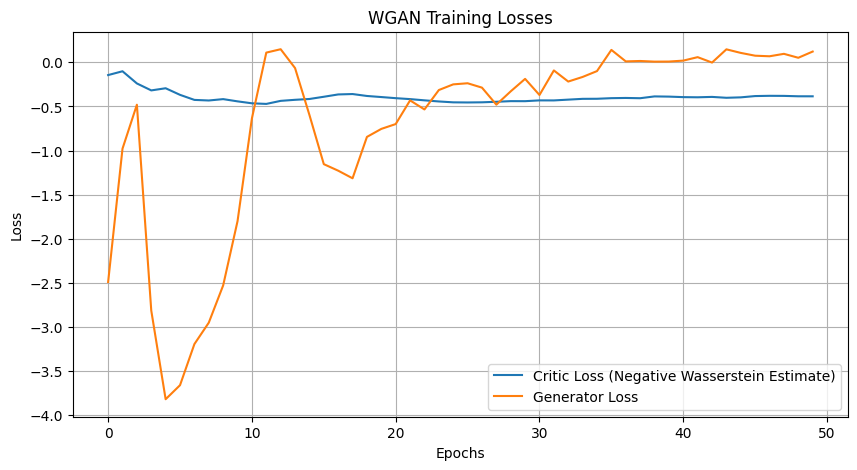

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(c_loss_history, label="Critic Loss (Negative Wasserstein Estimate)")
plt.plot(g_loss_history, label="Generator Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("WGAN Training Losses")
plt.legend()
plt.grid(True)
plt.show()

Output()

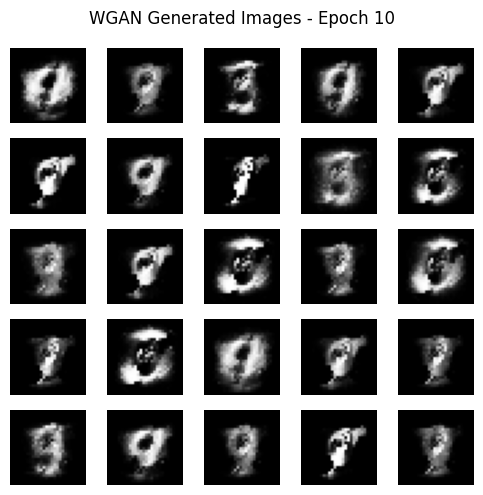

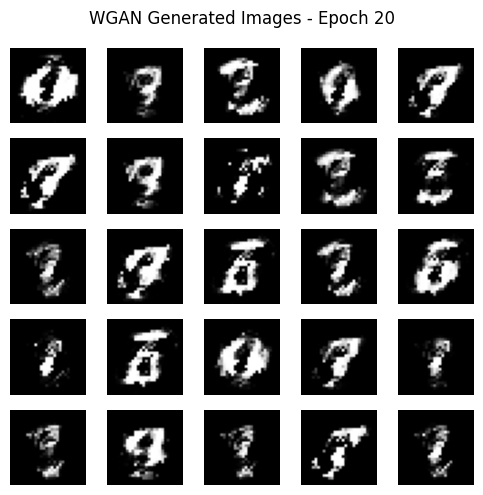

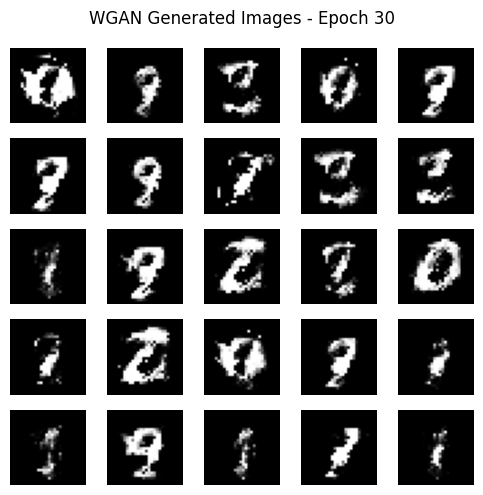

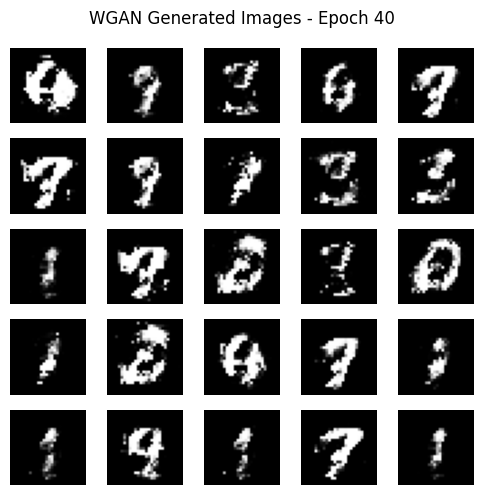

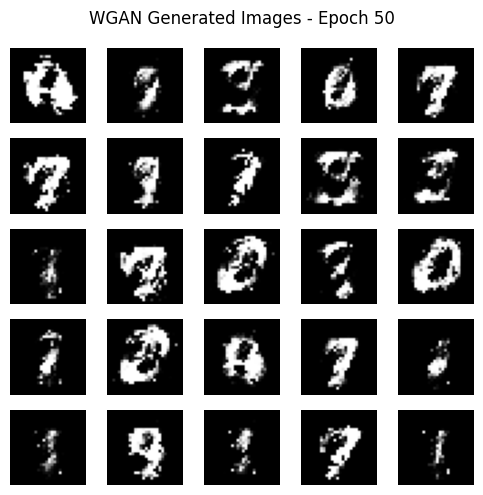

In [8]:
wgan_G = Generator(latent_dim, num_classes=10).to(device)
wgan_C = Critic(num_classes=10).to(device)

c_loss_history, g_loss_history = train_wgan(wgan_G, wgan_C, epochs=50, conditional=True)

torch.save(wgan_G.state_dict(), "wgan_generator_c.pth")
torch.save(wgan_C.state_dict(), "wgan_critic_c.pth")

***